# Credit ApprovaL
Notebook preparado para clasificación binaria con flujo limpio y reproducible.

**Dataset:** UCI Credit Approval — 690 instancias, 15 atributos (6 numéricos, 9 categóricos) anonimizados por razones de confidencialidad. Variable objetivo `A16`: `+` = crédito aprobado, `-` = crédito denegado.

**Pipeline:**
1. Carga de datos
2. Exploración inicial y visualización de clases
3. Preparación de tipos e imputación
4. Verificación del target mapeado (sin NaN silencioso)
5. Codificación de categóricas
6. Conversión a arrays NumPy
7. Split manual 75/25
8. Escalamiento Z-score (featureNormalize)
9. Modelo de regresión logística (implementación manual)
10. Evaluación de métricas


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import optimize

_ = (plt, sns)

## 1. Carga de datos

Se lee directamente el archivo `crx.data` descomprimido del ZIP de UCI. Los valores `?` se interpretan como `NaN` directamente en la carga.

In [52]:
file_path = r'6-Credit+Approval/crx.data'
column_names = [f'A{i}' for i in range(1, 17)]

df = pd.read_csv(
    file_path,
    header=None,
    names=column_names,
    na_values='?'
)

df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


## 2. Exploración inicial del dataset

Se revisa estructura, tipos, faltantes y distribución de la clase objetivo. Se incluye un heatmap de correlación entre las variables numéricas conocidas.

Dimensiones del dataset: (690, 16)

Primeras filas:
  A1     A2     A3 A4 A5 A6 A7    A8 A9 A10  A11 A12 A13    A14  A15 A16
0  b  30.83  0.000  u  g  w  v  1.25  t   t    1   f   g  202.0    0   +
1  a  58.67  4.460  u  g  q  h  3.04  t   t    6   f   g   43.0  560   +
2  a  24.50  0.500  u  g  q  h  1.50  t   f    0   f   g  280.0  824   +
3  b  27.83  1.540  u  g  w  v  3.75  t   t    5   t   g  100.0    3   +
4  b  20.17  5.625  u  g  w  v  1.71  t   f    0   f   s  120.0    0   +

Tipos de datos:
A1         str
A2     float64
A3     float64
A4         str
A5         str
A6         str
A7         str
A8     float64
A9         str
A10        str
A11      int64
A12        str
A13        str
A14    float64
A15      int64
A16        str
dtype: object

Valores faltantes por columna:
A1     12
A2     12
A3      0
A4      6
A5      6
A6      9
A7      9
A8      0
A9      0
A10     0
A11     0
A12     0
A13     0
A14    13
A15     0
A16     0
dtype: int64

Distribución de la clase objetivo

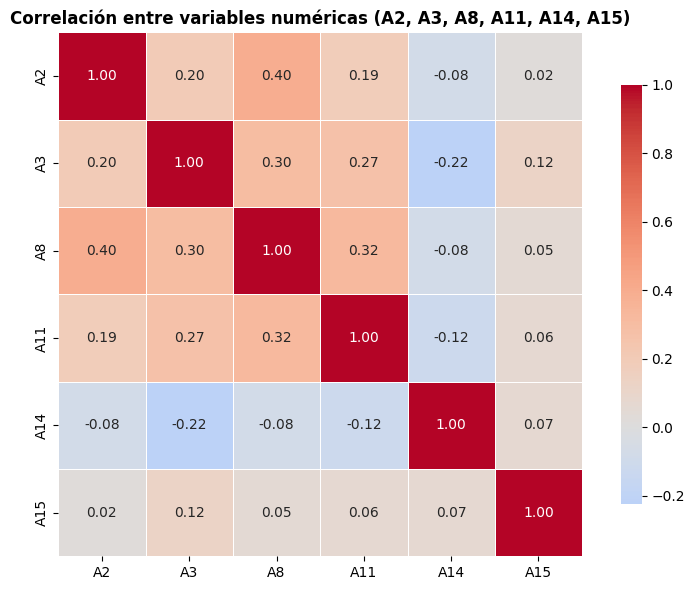

In [53]:
# Configurar pandas para mostrar toda la información sin truncar
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)

print('Dimensiones del dataset:', df.shape)
print('\nPrimeras filas:')
print(df.head())
print('\nTipos de datos:')
print(df.dtypes)
print('\nValores faltantes por columna:')
print(df.isna().sum())
print('\nDistribución de la clase objetivo A16:')
class_counts = df['A16'].value_counts(dropna=False)
class_percent = df['A16'].value_counts(normalize=True, dropna=False) * 100
print(class_counts)
print('\nPorcentaje por clase:')
print(class_percent.round(2))

if len(class_counts) == 2:
    ratio = class_counts.max() / class_counts.min()
    print('\nRelación mayoritaria/minoritaria:', round(ratio, 2))
    if ratio <= 1.5:
        print('Conclusión: sin desbalance fuerte.')
    else:
        print('Conclusión: hay desbalance — se aplicará upsampling en train.')

# Heatmap de correlación entre variables numéricas
numeric_preview = ['A2','A3','A8','A11','A14','A15']
num_data = df[numeric_preview].copy()
for col in num_data.columns:
    num_data[col] = pd.to_numeric(num_data[col], errors='coerce')
corr_matrix = num_data.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlación entre variables numéricas (A2, A3, A8, A11, A14, A15)', fontweight='bold')
plt.tight_layout(); plt.show()


### Visualización de la distribución de clases

Representación gráfica del balance entre las clases del target.

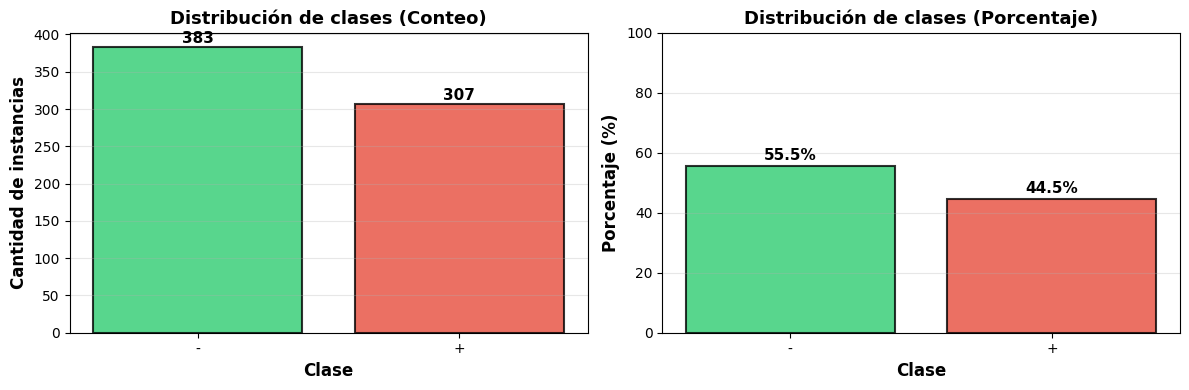

In [54]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico 1: Conteo absoluto
axes[0].bar(class_counts.index, class_counts.values, color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black', linewidth=1.5)
axes[0].set_xlabel('Clase', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cantidad de instancias', fontsize=12, fontweight='bold')
axes[0].set_title('Distribución de clases (Conteo)', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=11)

# Gráfico 2: Porcentaje
axes[1].bar(class_percent.index, class_percent.values, color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black', linewidth=1.5)
axes[1].set_xlabel('Clase', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Porcentaje (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Distribución de clases (Porcentaje)', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 100)
axes[1].grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for i, v in enumerate(class_percent.values):
    axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## 3. Preparación de tipos de datos e imputación

En este dataset hay variables numéricas y categóricas mezcladas. Se convierten explícitamente las numéricas, se imputan con **mediana** los faltantes numéricos y con **moda** los categóricos. Finalmente se mapea el target: `+`→1, `-`→0.

In [55]:
# Columnas numéricas y categóricas según la información oficial del dataset
numeric_cols = ['A2', 'A3', 'A8', 'A11', 'A14', 'A15']
categorical_cols = [col for col in column_names if col not in numeric_cols + ['A16']]

# Conversión explícita de columnas numéricas
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Imputación: mediana para numéricas, moda para categóricas
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode(dropna=True)[0])

# Codificación del target: + = aprobado (1), - = denegado (0)
df['A16'] = df['A16'].map({'+': 1, '-': 0})

df.head()


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,1
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,1
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,1
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,1
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,1


## 4. Verificación del target mapeado

Si existieran valores distintos de `+` y `-` en `A16`, el `.map()` produciría `NaN` silenciosamente, contaminando el entrenamiento. Se verifica y se corrige si es necesario.

In [56]:
# Verificación crítica: mapeo no debe producir NaN en el target
n_nan_target = df['A16'].isna().sum()
if n_nan_target > 0:
    print(f'ADVERTENCIA: {n_nan_target} NaN en A16 tras el mapeo.')
    print('Valores únicos encontrados:', df['A16'].unique())
    df = df.dropna(subset=['A16'])
    print(f'Filas eliminadas con target inválido. Quedan: {len(df)}')
else:
    print('✓ Target A16 mapeado correctamente — sin valores NaN.')

print('Distribución final del target:')
print(df['A16'].value_counts())


✓ Target A16 mapeado correctamente — sin valores NaN.
Distribución final del target:
A16
0    383
1    307
Name: count, dtype: int64


## 5. Codificación de variables categóricas

Las columnas categóricas se convierten en variables numéricas con `get_dummies` y `drop_first=True` para evitar multicolinealidad perfecta. Se imprime el listado completo de columnas generadas para auditar el encoding.

In [57]:
X = pd.get_dummies(df.drop(columns=['A16']), columns=categorical_cols, drop_first=True)
y = df['A16'].values.astype(np.float32).reshape(-1, 1)

print('Shape de X (después de encoding):', X.shape)
print('Shape de y:', y.shape)
print(f'\nColumnas generadas ({len(X.columns)} total):')
print(X.columns.tolist())
X.head()


Shape de X (después de encoding): (690, 37)
Shape de y: (690, 1)

Columnas generadas (37 total):
['A2', 'A3', 'A8', 'A11', 'A14', 'A15', 'A1_b', 'A4_u', 'A4_y', 'A5_gg', 'A5_p', 'A6_c', 'A6_cc', 'A6_d', 'A6_e', 'A6_ff', 'A6_i', 'A6_j', 'A6_k', 'A6_m', 'A6_q', 'A6_r', 'A6_w', 'A6_x', 'A7_dd', 'A7_ff', 'A7_h', 'A7_j', 'A7_n', 'A7_o', 'A7_v', 'A7_z', 'A9_t', 'A10_t', 'A12_t', 'A13_p', 'A13_s']


,A2,A3,A8,A11,A14,A15,A1_b,A4_u,A4_y,A5_gg,A5_p,A6_c,A6_cc,A6_d,A6_e,A6_ff,A6_i,A6_j,A6_k,A6_m,A6_q,A6_r,A6_w,A6_x,A7_dd,A7_ff,A7_h,A7_j,A7_n,A7_o,A7_v,A7_z,A9_t,A10_t,A12_t,A13_p,A13_s
0,30.83,0.000,1.25,1,202.0,0,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,True,False,False,False
1,58.67,4.460,3.04,6,43.0,560,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,True,False,False,False
2,24.50,0.500,1.50,0,280.0,824,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False
3,27.83,1.540,3.75,5,100.0,3,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,True,True,False,False
4,20.17,5.625,1.71,0,120.0,0,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,False,False,False,True


## 6. Conversión a arrays para modelado

Se convierte el DataFrame codificado a matrices NumPy (`float32`) para alimentar una red neuronal en PyTorch u otros modelos implementados manualmente.

In [58]:
X = X.values.astype(np.float32)
y = y.astype(np.float32)

print('Shape de X:', X.shape)
print('Shape de y:', y.shape)

Shape de X: (690, 37)
Shape de y: (690, 1)


## 7. Split manual 75/25

Se realiza un corte manual conservando el orden de las filas: 75% para entrenamiento y 25% para prueba.

In [59]:
# Split manual 75/25 sobre los arrays completos
X_all = X
y_all = y.reshape(-1)  # convertir target a vector 1D

split = int(0.75 * len(X_all))

X_train_np, y_train_np = X_all[:split], y_all[:split]
X_test_np, y_test_np = X_all[split:], y_all[split:]

# Variables de trabajo para mantener compatibilidad con el resto del notebook
X = X_train_np
y = y_train_np

print(f'Forma de X completo: {X_all.shape}')
print(f'Forma de y completo: {y_all.shape}')
print(f'\nEjemplos de entrenamiento: {X_train_np.shape[0]}')
print(f'Ejemplos de prueba:        {X_test_np.shape[0]}')

Forma de X completo: (690, 37)
Forma de y completo: (690,)

Ejemplos de entrenamiento: 517
Ejemplos de prueba:        173


## 8. Escalamiento

Normalización Z-score calculada solo sobre el set de entrenamiento. Se aplica al test con los mismos µ y σ del train para evitar data leakage.

In [60]:
import numpy as np

def sigmoide(z):
    z=np.array(z)
    g= 1/ (1+ np.exp(-z))
    return g
# Prueba de la función
z = [0, 0.5, 0.75, 1]
g = sigmoide(z)
print(f'g({z}) = {g}')
print(f'sigmoid(0) debe ser exactamente 0.5: {sigmoide(0)}')

g([0, 0.5, 0.75, 1]) = [0.5        0.62245933 0.6791787  0.73105858]
sigmoid(0) debe ser exactamente 0.5: 0.5


In [61]:
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

X_train_np, mu, sigma = featureNormalize(X_train_np)
X_test_np = (X_test_np - mu) / sigma

X_train_np.shape, X_test_np.shape


((517, 37), (173, 37))

Termino de iterseccion + Costo inicial


In [62]:
# Verificación para evitar errores si se ejecuta fuera de orden
if 'X_train_np' not in globals() or 'y_train_np' not in globals():
    raise RuntimeError('Primero ejecuta la celda 18 (Split manual 75/25).')

m, n = X_train_np.shape
X_train_norm = np.concatenate([np.ones((m, 1)), X_train_np], axis=1)

print(f'Forma de X_train con intercepción: {X_train_norm.shape}')

def calcularCosto(theta, X, y):
    y = np.asarray(y).reshape(-1)
    h = sigmoide(X.dot(theta.T)).reshape(-1)
    m = y.size
    h = np.clip(h, 1e-10, 1 - 1e-10)
    J = -(1 / m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    return J

# Verificar costo inicial con theta = 0
theta_init = np.zeros(X_train_norm.shape[1])
costo_inicial = calcularCosto(theta_init, X_train_norm, y_train_np)

print(f'\nCosto inicial (theta=0): {costo_inicial:.4f}')
print(f'Costo esperado (log 2):  {np.log(2):.4f}')

Forma de X_train con intercepción: (517, 38)

Costo inicial (theta=0): 0.6931
Costo esperado (log 2):  0.6931


Descenso por el Gradiente

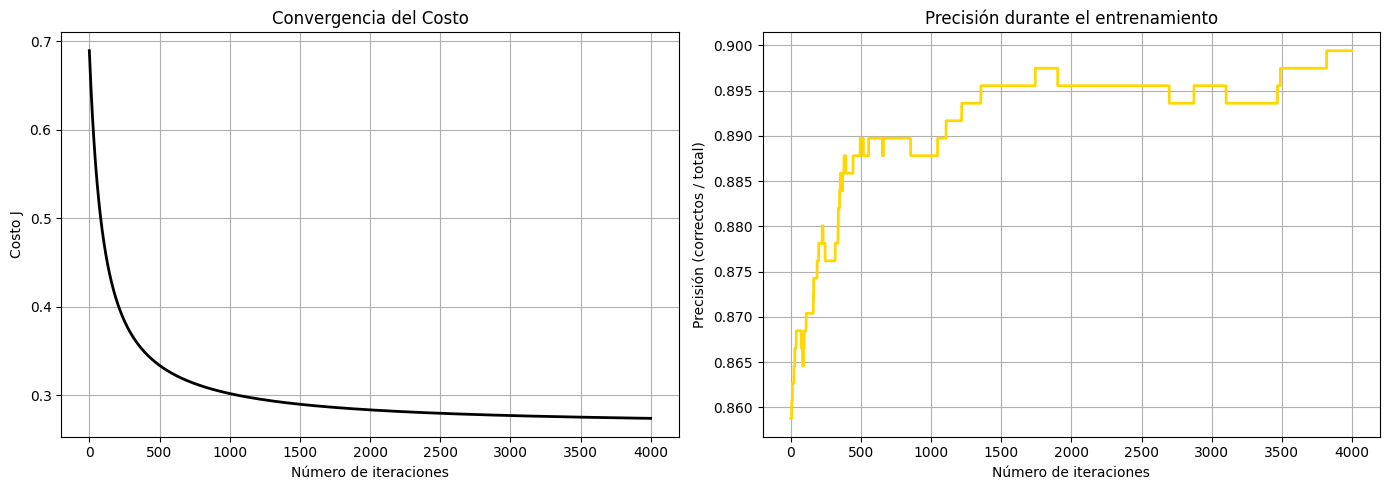

theta calculado por el descenso por el gradiente: [-0.27311493  0.25250783 -0.00464011  0.16216797  0.58075988] ...
Costo final tras 4000 iteraciones:        0.2737
Precisión final en entrenamiento:  89.94 %


In [63]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []
    p_history = []

    for i in range(num_iters):
        h = sigmoide(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCosto(theta, X, y))

        # Precisión = suma(y_pred == y_real) / m
        y_pred = np.round(sigmoide(X.dot(theta.T)))
        prec = np.sum(y_pred == y) / m
        p_history.append(prec)

    return theta, J_history, p_history

alpha = 0.01
num_iters = 4000

theta = np.zeros(X_train_norm.shape[1])
theta, J_history, p_history = descensoGradiente(theta, X_train_norm, y_train_np, alpha, num_iters)

# Costo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(np.arange(len(J_history)), J_history, color='black', lw=2)
ax1.set_xlabel('Número de iteraciones')
ax1.set_ylabel('Costo J')
ax1.set_title('Convergencia del Costo')
ax1.grid(True)

# Precisión
ax2.plot(np.arange(len(p_history)), p_history, color='gold', lw=2)
ax2.set_xlabel('Número de iteraciones')
ax2.set_ylabel('Precisión (correctos / total)')
ax2.set_title('Precisión durante el entrenamiento')
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f'theta calculado por el descenso por el gradiente: {theta[:5]} ...')
print(f'Costo final tras {num_iters} iteraciones:        {J_history[-1]:.4f}')
print(f'Precisión final en entrenamiento:  {p_history[-1]*100:.2f} %')

optimizacion con scpipy,optimaze

In [64]:
def costFunction(theta, X, y):
    m = y.size
    h = sigmoide(X.dot(theta.T))
    h = np.clip(h, 1e-10, 1 - 1e-10)
    J    = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    grad = (1 / m) * (h - y).dot(X)
    return J, grad

initial_theta = np.zeros(X_train_norm.shape[1])
cost_test, grad_test = costFunction(initial_theta, X_train_norm, y_train_np)

print(f'Costo en theta=0:       {cost_test:.4f}')
print(f'Gradiente (primeros 5): {grad_test[:5]}')

res = optimize.minimize(costFunction,
                        initial_theta,
                        (X_train_norm, y_train_np),
                        jac=True,
                        method='TNC',
                        options={'maxfun': 5000})  # TNC usa maxfun, no maxiter

cost_opt  = res.fun
theta_opt = res.x

print(f'\nCosto óptimo (scipy):      {cost_opt:.4f}')
print(f'Theta óptimo (primeros 5): {theta_opt[:5]}')

Costo en theta=0:       0.6931
Gradiente (primeros 5): [ 0.02804642 -0.08888313 -0.11618529 -0.16993475 -0.19340973]

Costo óptimo (scipy):      0.2620
Theta óptimo (primeros 5): [ 0.05319691  0.2793311  -0.16264622  0.0727998   0.92770255]


predicciones

In [65]:
def prediccion(theta, X):
    m = X.shape[0]
    p = np.zeros(m)
    p = np.round(sigmoide(X.dot(theta.T)))
    return p

# Normalizar X_test con mu y sigma del entrenamiento
X_test_float = X_test_np.astype(float) 
X_test_norm = (X_test_float - mu) / sigma
m_test      = X_test_norm.shape[0]
X_test_norm = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

# Predicciones
theta_final=theta
p_train = prediccion(theta_final, X_train_norm)
p_test  = prediccion(theta_final, X_test_norm)

acc_train = np.mean(p_train == y_train_np) * 100
acc_test  = np.mean(p_test  == y_test_np)  * 100

print(f'Precisión de entrenamiento: {acc_train:.2f} %')
print(f'Precisión de prueba:        {acc_test:.2f} %')

Precisión de entrenamiento: 89.94 %
Precisión de prueba:        78.61 %


## Prediccion de nuevos creditos

Esta celda permite predecir nuevos creditos usando el modelo entrenado.
Entrada: matriz con nuevas observaciones (mismas features del entrenamiento, antes de escalar).
Salida: probabilidad de aprobacion y clase predicha (1=aprobado, 0=denegado).

In [66]:
def predecir_nuevos_creditos(X_nuevos, theta, mu, sigma, umbral=0.5):
    X_nuevos = np.asarray(X_nuevos, dtype=float)

    if X_nuevos.ndim == 1:
        X_nuevos = X_nuevos.reshape(1, -1)

    if X_nuevos.shape[1] != mu.shape[0]:
        raise ValueError(
            f'Cada registro debe tener {mu.shape[0]} features; recibidas: {X_nuevos.shape[1]}'
        )

    # Escalar con parametros del entrenamiento
    X_nuevos_norm = (X_nuevos - mu) / sigma
    X_nuevos_norm = np.concatenate([np.ones((X_nuevos_norm.shape[0], 1)), X_nuevos_norm], axis=1)

    probs = sigmoide(X_nuevos_norm.dot(theta.T)).reshape(-1)
    preds = (probs >= umbral).astype(int)

    return probs, preds


if 'theta_final' not in globals():
    theta_final = theta

# Ejemplo: tomar 5 registros del test y reconstruirlos a escala original
X_nuevos_demo = (X_test_np[:5] * sigma) + mu

probs_demo, preds_demo = predecir_nuevos_creditos(
    X_nuevos=X_nuevos_demo,
    theta=theta_final,
    mu=mu,
    sigma=sigma,
    umbral=0.5
)

print('=== PREDICCION DE NUEVOS CREDITOS ===')
for i, (prob, pred) in enumerate(zip(probs_demo, preds_demo), start=1):
    estado = 'Aprobado' if pred == 1 else 'Denegado'
    print(f'Credito nuevo {i:2d}: Prob={prob:.4f} | Pred={pred} ({estado})')


=== PREDICCION DE NUEVOS CREDITOS ===
Credito nuevo  1: Prob=0.7245 | Pred=1 (Aprobado)
Credito nuevo  2: Prob=0.9013 | Pred=1 (Aprobado)
Credito nuevo  3: Prob=0.9623 | Pred=1 (Aprobado)
Credito nuevo  4: Prob=0.6692 | Pred=1 (Aprobado)
Credito nuevo  5: Prob=0.9183 | Pred=1 (Aprobado)
